# Latent-bridge v2 concept swaps — GPT-2 XL

Do J-lens swaps of a country the prompt never names still change the answer when the subject is
not a landmark but a city, a person, a company or a food? `data/experiments/latent-bridge-v2.json`
asks e.g. *"Toyota is a company from a country where the main language is"*; swapping the J-lens
coordinates of *Japan* for *Italy* should make GPT-2 XL answer *Italian*. Every item is answered
correctly without intervention, and GPT-2 XL names the subject's country and the country's
language when asked directly (`latent_bridge_v2_build.ipynb`).

**Answer (this run).** Yes, as well as on landmarks. Clamping the J-lens coordinates of the country flips 91.9% of
the 1416 trials to the swapped country's language (α = 2, band 12–36; 95% CI 90.4–93.3%), against
85.9% for logit-lens directions (α = 2, band 16–40), 64.1% for difference-of-means probes and
≤ 3.3% for random directions. All five families behave alike (J: 89–94%). Below layer 24 only
J-lens and probe directions work: at α = 4, band 8–16, J flips 68% and logit-lens directions 3%.

## Method

Same swap as `concept_swap.ipynb`, on the 1416 items of `latent-bridge-v2` (354 subjects in five
families, 4 swap countries each).

**Directions.** J-lens: `v_t = J_lᵀ C(γ ⊙ u_t)` for the country token t (`u_t` the unembedding
row, `γ`, `C` the `ln_f` gain and centering). Logit lens: the same with `J_l = I`. Probe: the
difference-of-means direction of the country at layer l, from the neutral templates of
`concept-probe-templates.json`. Random: a random direction per position with the norm of the
J-lens update.

**Clamp.** For source s and target t, `V = [v_s v_t]`, `c = V⁺h`; after every block of the band,
`h ← h + V(c* − V⁺h)` with `c* = c_clean + α(swap(c_clean) − c_clean)`, at every position except
BOS.

**Grid.** Bands 8–16, 16–24, 24–32, 32–40, 40–47, 12–36, 16–40 (half-open block-output ranges),
α ∈ {1, 2, 4}, four direction modes: 84 patched passes per batch.

**Success.** The greedy next token is a spelling of the swap country's language
(`jlens.evaluation.spelling_ids`). Wilson 95% intervals. Lens: `snapshot_lens_134.pt`, the
GPT-2 XL lens used by `concept_swap.ipynb`.

**Batching.** Trials are sorted by length, right-padded and run 64 at a time, each row with its
own basis; rows are read at their last real token (GPT-2 is causal, so padding never reaches a
real token). Outputs stay on the GPU until one transfer per batch.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from transformers import AutoTokenizer

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import spelling_ids
from jlens.hooks import ActivationRecorder

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", None)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
OUT_DIR = RUN_DIR / "swap"
CACHE = OUT_DIR / "swap_trials_latent-bridge-v2.csv"
V1_CACHE = OUT_DIR / "swap_trials_latent-bridge.csv"  # concept_swap.ipynb, for comparison
PROBE_PATH = OUT_DIR / "probe_vectors_latent-bridge-v2.pt"
BANDS = ["8-16", "16-24", "24-32", "32-40", "40-47", "12-36", "16-40"]  # half-open block-output ranges
ALPHAS = [1.0, 2.0, 4.0]
MODES = ["J", "logit", "probe", "random"]
BATCH_SIZE = 64  # trials per forward pass
OUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

## 1. Trials

In [4]:
data = json.loads((Path(REPO_DIR) / "data/experiments/latent-bridge-v2.json").read_text())
trials = pd.DataFrame([
    {"family": item["family"], "name": item["name"], "subject": item["subject"], "prompt": item["prompt"],
     "source": item["intermediate"], "target": item["swap_to"], "answer": item["answer"],
     "swap_answer": item["swap_answer"]}
    for item in data["items"]
])
FAMILIES = list(dict.fromkeys(trials.family))
tok = AutoTokenizer.from_pretrained(MODEL_ID)
assert all(len(tok.encode(" " + c)) == 1 for c in set(trials.source) | set(trials.target))
assert all(spelling_ids(tok, w) for w in set(trials.answer) | set(trials.swap_answer))
print(f"filtered on: {data['filtered_on']}")
display(trials.groupby("family", sort=False).agg(subjects=("subject", "nunique"), trials=("name", "size"),
                                                  countries=("source", "nunique")))
trials.groupby("family", sort=False).head(1)[["name", "prompt", "answer", "swap_answer"]]

filtered on: {'model': 'openai-community/gpt2-xl', 'dtype': 'float32', 'bos': '<|endoftext|>', 'filter': 'hop-1 country and hop-2 language best among candidates; greedy composed answer correct'}


,subjects,trials,countries
family,,,
landmark,71,284,20
city,98,392,21
person,83,332,21
brand,49,196,15
food,53,212,12


,name,prompt,answer,swap_answer
0,the Eiffel Tower:France->Netherlands,The Eiffel Tower is in a country where the main language is,French,Dutch
284,Lyon:France->Spain,Lyon is a city in a country where the main language is,French,Spanish
676,Napoleon:France->Mexico,Napoleon was born in a country where the main language is,French,Spanish
1008,Renault:France->Japan,Renault is a company from a country where the main language is,French,Japanese
1204,croissant:France->Thailand,Croissant comes from a country where the main language is,French,Thai


## 2. Probe directions and run

Probe vectors (22 countries × 20 templates) are cached to `PROBE_PATH`; the swap results to
`CACHE` (~10 min on a V100). Both are skipped when present; the model is then not loaded.

In [5]:
CONCEPTS = sorted(set(trials.source) | set(trials.target))
PROBE_TEMPLATES = json.load(open(Path(REPO_DIR) / "data/experiments/concept-probe-templates.json"))["templates"]
need_run = not (CACHE.exists() and set(pd.read_csv(CACHE, usecols=["mode"])["mode"]) == set(MODES))
probe_cache = torch.load(PROBE_PATH) if PROBE_PATH.exists() else None
if probe_cache is not None and (probe_cache["concepts"], probe_cache["templates"]) != (CONCEPTS, PROBE_TEMPLATES):
    probe_cache = None
model = None
if need_run or probe_cache is None:
    model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    jacobians = {layer: J.to(DEVICE) for layer, J in lens.jacobians.items()}
    W_U = model._lm_head.weight.float()
    gamma = model._final_norm.weight.float()
    LAYERS = range(model.n_layers - 1)

if probe_cache is None:
    @torch.no_grad()
    def concept_means():
        """[layer, concept, d] block output at the concept token, averaged over templates."""
        sums = torch.zeros(len(LAYERS), len(CONCEPTS), model.d_model, device=DEVICE)
        pairs = [(c, template) for c in range(len(CONCEPTS)) for template in PROBE_TEMPLATES]
        for start in range(0, len(pairs), BATCH_SIZE):
            chunk = pairs[start:start + BATCH_SIZE]
            encoded, positions = [], []
            for c, template in chunk:
                ids = model.encode(template.format(x=CONCEPTS[c]))[0]
                position = model.encode(template.split("{x}")[0].rstrip()).shape[1]
                assert int(ids[position]) == tok.encode(" " + CONCEPTS[c])[0], (template, CONCEPTS[c])
                encoded.append(ids)
                positions.append(position)
            ids = pad_sequence(encoded, batch_first=True, padding_value=tok.eos_token_id)
            rows = torch.arange(len(chunk), device=DEVICE)
            index = torch.tensor([c for c, _ in chunk], device=DEVICE)
            with ActivationRecorder(model.layers, at=LAYERS) as recorder:
                model.forward(ids)
            for layer in LAYERS:
                sums[layer].index_add_(0, index, recorder.activations[layer][rows, positions].float())
        return sums / len(PROBE_TEMPLATES)

    means = concept_means()
    torch.save({"concepts": CONCEPTS, "templates": PROBE_TEMPLATES,
                "vectors": (means - means.mean(1, keepdim=True)).cpu()}, PROBE_PATH)
    probe_cache = torch.load(PROBE_PATH)
probe_vectors = probe_cache["vectors"]
print(f"{len(CONCEPTS)} concepts x {len(PROBE_TEMPLATES)} templates, vectors {tuple(probe_vectors.shape)}")

22 concepts x 20 templates, vectors (47, 22, 1600)


In [6]:
if need_run:
    concept_index = {concept: i for i, concept in enumerate(CONCEPTS)}
    concept_token = {concept: tok.encode(" " + concept)[0] for concept in CONCEPTS}
    probe_on_device = probe_vectors.to(DEVICE)

    class Bases:
        """Per-row V = [v_s v_t] (stored transposed, [batch, 2, d]) and pseudoinverses, cached by (layer, kind)."""

        def __init__(self, chunk):
            tokens = torch.tensor([[concept_token[s], concept_token[t]] for s, t in zip(chunk.source, chunk.target,
                                                                                           strict=True)], device=DEVICE)
            g = gamma * W_U[tokens]  # [batch, 2, d]
            self.unembed = g - g.mean(-1, keepdim=True)
            self.concepts = torch.tensor([[concept_index[s], concept_index[t]] for s, t in zip(
                chunk.source, chunk.target, strict=True)], device=DEVICE)
            self.cache = {}

        def __call__(self, layer, mode):
            kind = "J" if mode == "random" else mode  # random mode uses the J basis for the update norm
            if (layer, kind) not in self.cache:
                if kind == "probe":
                    Vt = probe_on_device[layer][self.concepts]
                elif kind == "logit":
                    Vt = self.unembed
                else:
                    Vt = self.unembed @ jacobians[layer]
                self.cache[layer, kind] = (Vt, torch.linalg.pinv(Vt.transpose(1, 2)))
            return self.cache[layer, kind]

    class Swap:
        """Clamp each row's (source, target) coordinates at every hooked layer to swapped clean values."""

        def __init__(self, layers, bases, alpha, mode, clean):
            self.bases, self.alpha, self.mode, self.clean = bases, alpha, mode, clean
            self.handles = [model.layers[layer].register_forward_hook(self.hook(layer)) for layer in layers]

        def hook(self, layer):
            def fn(module, inputs, output):
                h = output if torch.is_tensor(output) else output[0]
                Vt, V_pinv = self.bases(layer, self.mode)
                c = torch.einsum("btd,bkd->btk", h[:, 1:].float(), V_pinv)  # BOS skipped
                c_clean = torch.einsum("btd,bkd->btk", self.clean[layer][:, 1:].float(), V_pinv)
                target = c_clean + self.alpha * (c_clean[..., [1, 0]] - c_clean)
                update = torch.einsum("btk,bkd->btd", target - c, Vt)
                if self.mode == "random":
                    direction = torch.randn_like(update)
                    update = direction / direction.norm(dim=-1, keepdim=True) * update.norm(dim=-1, keepdim=True)
                h = h.clone()
                h[:, 1:] += update.to(h.dtype)
                return h if torch.is_tensor(output) else (h, *output[1:])
            return fn

        def __enter__(self):
            return self

        def __exit__(self, *exc):
            for handle in self.handles:
                handle.remove()

    spelling_cache = {}

    def spelling_index(words):
        # [n, K] spelling ids per word, padded by repeating each row's first id.
        rows = []
        for word in words:
            if word not in spelling_cache:
                spelling_cache[word] = sorted(spelling_ids(tok, word))
            rows.append(spelling_cache[word])
        width = max(map(len, rows))
        return torch.tensor([row + row[:1] * (width - len(row)) for row in rows], device=DEVICE)

    def rank_and_hit(logits, index):
        # Best rank over each row's spellings, and whether the greedy token is one of them.
        best = logits.gather(1, index).max(1).values
        return (logits > best[:, None]).sum(1) + 1, (index == logits.argmax(1, keepdim=True)).any(1)

    @torch.no_grad()
    def next_token_logits(ids, last):
        # Right padding needs no attention mask: GPT-2 is causal and each row is read at its last real token.
        hidden = model.forward(ids).last_hidden_state  # ln_f already applied
        return model._lm_head(hidden[torch.arange(len(ids), device=DEVICE), last]).float()

    SETTINGS = [(band, mode, alpha) for band in BANDS for mode in MODES for alpha in ALPHAS]
    encoded = [model.encode(prompt)[0] for prompt in trials.prompt]
    order = np.argsort([len(ids) for ids in encoded], kind="stable")  # similar lengths share a batch
    records = []
    for start in tqdm(range(0, len(order), BATCH_SIZE), desc="batches"):
        index = order[start:start + BATCH_SIZE]
        chunk = trials.iloc[index]
        ids = pad_sequence([encoded[i] for i in index], batch_first=True, padding_value=tok.eos_token_id)
        last = torch.tensor([len(encoded[i]) - 1 for i in index], device=DEVICE)
        answer, swap_answer = spelling_index(chunk.answer), spelling_index(chunk.swap_answer)
        with ActivationRecorder(model.layers, at=LAYERS) as recorder:
            base = next_token_logits(ids, last)
        clean = {layer: activation.detach() for layer, activation in recorder.activations.items()}
        bases = Bases(chunk)
        _, base_correct = rank_and_hit(base, answer)
        base_rank_swap, _ = rank_and_hit(base, swap_answer)
        outputs = []
        for band, mode, alpha in SETTINGS:
            layer_start, layer_stop = map(int, band.split("-"))
            with Swap(range(layer_start, layer_stop), bases, alpha, mode, clean):
                patched = next_token_logits(ids, last)
            rank_swap, success = rank_and_hit(patched, swap_answer)
            rank_answer, _ = rank_and_hit(patched, answer)
            outputs.append(torch.stack([patched.argmax(1), success.long(), rank_swap, rank_answer]))
        base_out = torch.stack([base.argmax(1), base_correct.long(), base_rank_swap]).cpu().numpy()
        outputs = torch.stack(outputs).cpu().numpy()  # [setting, 4, batch]: one sync per batch
        meta = chunk[["family", "name", "subject", "source", "target", "answer", "swap_answer"]].to_dict("records")
        for (band, mode, alpha), out in zip(SETTINGS, outputs, strict=True):
            for i, row in enumerate(meta):
                records.append({**row, "base_top1": base_out[0, i], "base_correct": bool(base_out[1, i]),
                                "base_rank_swap": base_out[2, i], "band": band, "mode": mode, "alpha": alpha,
                                "top1": out[0, i], "success": bool(out[1, i]), "rank_swap": out[2, i],
                                "rank_answer": out[3, i]})
    results = pd.DataFrame(records)
    decoded = {token: tok.decode([int(token)]) for token in set(results.top1) | set(results.base_top1)}
    results["top1"], results["base_top1"] = results.top1.map(decoded), results.base_top1.map(decoded)
    results.to_csv(CACHE, index=False)
    (OUT_DIR / "swap_latent-bridge-v2_run.json").write_text(json.dumps(
        {"model_id": MODEL_ID, "dtype": "float32", "lens": str(LENS_PATH), "bands": BANDS, "alphas": ALPHAS,
         "modes": MODES, "batch_size": BATCH_SIZE}, indent=1))
model = jacobians = None  # free GPU memory
results = pd.read_csv(CACHE, keep_default_na=False)
for column in ("base_correct", "success"):
    results[column] = results[column].astype(str).eq("True")
print(len(results), "rows")

118944 rows


## 3. Results

### Baseline (should be 100% by construction)

In [7]:
base = results.drop_duplicates("name")
base.groupby("family", sort=False).agg(trials=("base_correct", "size"), correct=("base_correct", "sum"),
                                       accuracy=("base_correct", "mean")).round(3)

,trials,correct,accuracy
family,,,
landmark,284,284,1.0
person,332,332,1.0
food,212,212,1.0
city,392,392,1.0
brand,196,196,1.0


### Swap success by direction, α and band (all trials)

In [8]:
def success_table(frame):
    return frame.groupby(["mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3)


def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return np.minimum(centre - half, p), np.maximum(centre + half, p)  # rounding never crosses p


def label_ends(ax, ends, gap=0.07):
    # Write each line's name at its right end, nudged apart vertically (in place of a legend).
    placed = []
    for y, text, color in sorted(ends):
        y = max(y, placed[-1] + gap) if placed else y
        placed.append(y)
        ax.annotate(text, xy=(1.01, y), xycoords=("axes fraction", "data"), color=color, fontsize=8,
                    va="center", annotation_clip=False)


def band_label(band):
    return f"layers {band.replace('-', '–')}"


COLORS = {"J": "#2a78d6", "logit": "#eb6834", "probe": "#1b9e5a", "random": "#52514e"}
NAMES = {"J": "J-lens directions", "logit": "logit-lens directions", "probe": "probe directions",
         "random": "random directions"}
BAND_TICKS = [band.replace("-", "–") for band in BANDS]


def band_panel(ax, frame, alpha):
    # Swap success vs band for every direction at one α, as in concept_swap.ipynb.
    grouped = frame[frame.alpha.eq(alpha)].groupby(["mode", "band"]).success.agg(["sum", "size"])
    ends = []
    for mode, color in COLORS.items():
        sub = grouped.loc[mode].loc[BANDS]
        rate = sub["sum"] / sub["size"]
        lo, hi = wilson(sub["sum"], sub["size"])
        ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color, marker="o", ms=4,
                    lw=1.8, capsize=2)
        ends.append((rate.iloc[-1], NAMES[mode], color))
    label_ends(ax, ends)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)


correct = results[results.base_correct]
success_table(correct)

band           8-16  16-24  24-32  32-40  40-47  12-36  16-40
mode   alpha                                                 
J      1.0    0.044  0.106  0.296  0.706  0.595  0.660  0.792
       2.0    0.359  0.586  0.871  0.888  0.785  0.919  0.895
       4.0    0.677  0.805  0.887  0.523  0.347  0.742  0.528
logit  1.0    0.000  0.001  0.069  0.645  0.590  0.352  0.657
       2.0    0.002  0.016  0.621  0.848  0.757  0.844  0.859
       4.0    0.031  0.153  0.819  0.444  0.294  0.670  0.434
probe  1.0    0.198  0.405  0.525  0.395  0.277  0.581  0.563
       2.0    0.437  0.602  0.641  0.401  0.326  0.540  0.444
       4.0    0.417  0.450  0.392  0.215  0.252  0.237  0.187
random 1.0    0.001  0.001  0.001  0.001  0.001  0.002  0.004
       2.0    0.002  0.004  0.004  0.007  0.010  0.015  0.020
       4.0    0.018  0.017  0.012  0.018  0.009  0.033  0.016

### Best setting per direction, with Wilson 95% intervals

In [9]:
grouped = correct.groupby(["mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby("mode")["sum"].idxmax()].set_index("mode").loc[MODES]
best["rate"] = best["sum"] / best["size"]
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
best.round(3)

,alpha,band,sum,size,rate,CI lo,CI hi
mode,,,,,,,
J,2.0,12-36,1302,1416,0.919,0.904,0.933
logit,2.0,16-40,1217,1416,0.859,0.840,0.877
probe,2.0,24-32,907,1416,0.641,0.615,0.665
random,4.0,12-36,47,1416,0.033,0.025,0.044


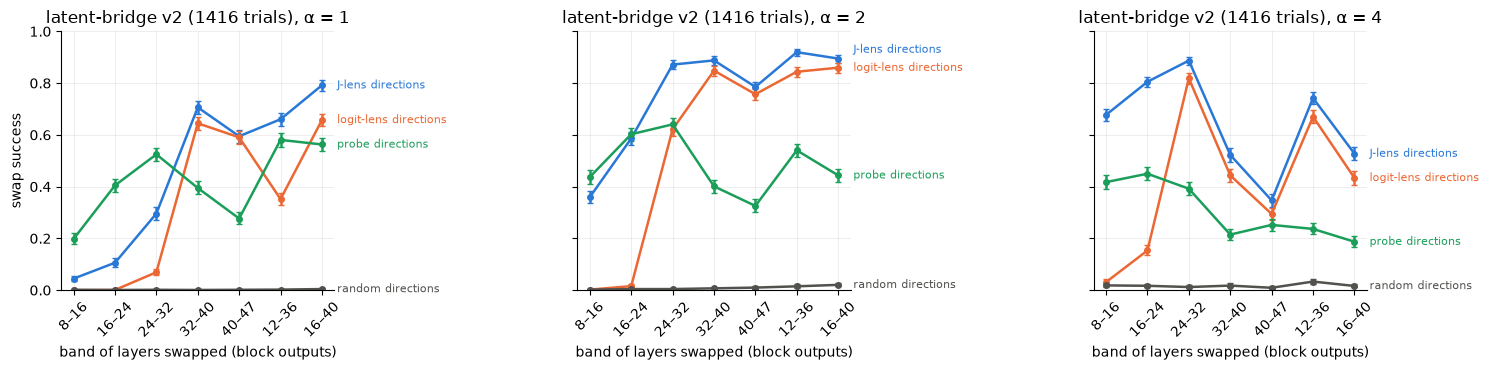

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, alpha in zip(axes, ALPHAS, strict=True):
    band_panel(ax, correct, alpha)
    ax.set_title(f"latent-bridge v2 (1416 trials), α = {alpha:g}")
    ax.set_xticks(range(len(BANDS)), BAND_TICKS, rotation=45)
    ax.set_xlabel("band of layers swapped (block outputs)")
axes[0].set_ylabel("swap success")
fig.tight_layout(w_pad=9)
plt.show()

### By subject family

Each direction at its pooled best setting (above), split by family; then the full band × α grid
per family, as in `concept_swap.ipynb`. Wilson 95% intervals.

,"J-lens directions (α = 2, layers 12–36)","logit-lens directions (α = 2, layers 16–40)","probe directions (α = 2, layers 24–32)","random directions (α = 4, layers 12–36)"
family,,,,
landmark,0.894,0.859,0.630,0.021
city,0.939,0.865,0.668,0.031
person,0.916,0.828,0.608,0.048
brand,0.913,0.878,0.628,0.046
food,0.929,0.882,0.665,0.019


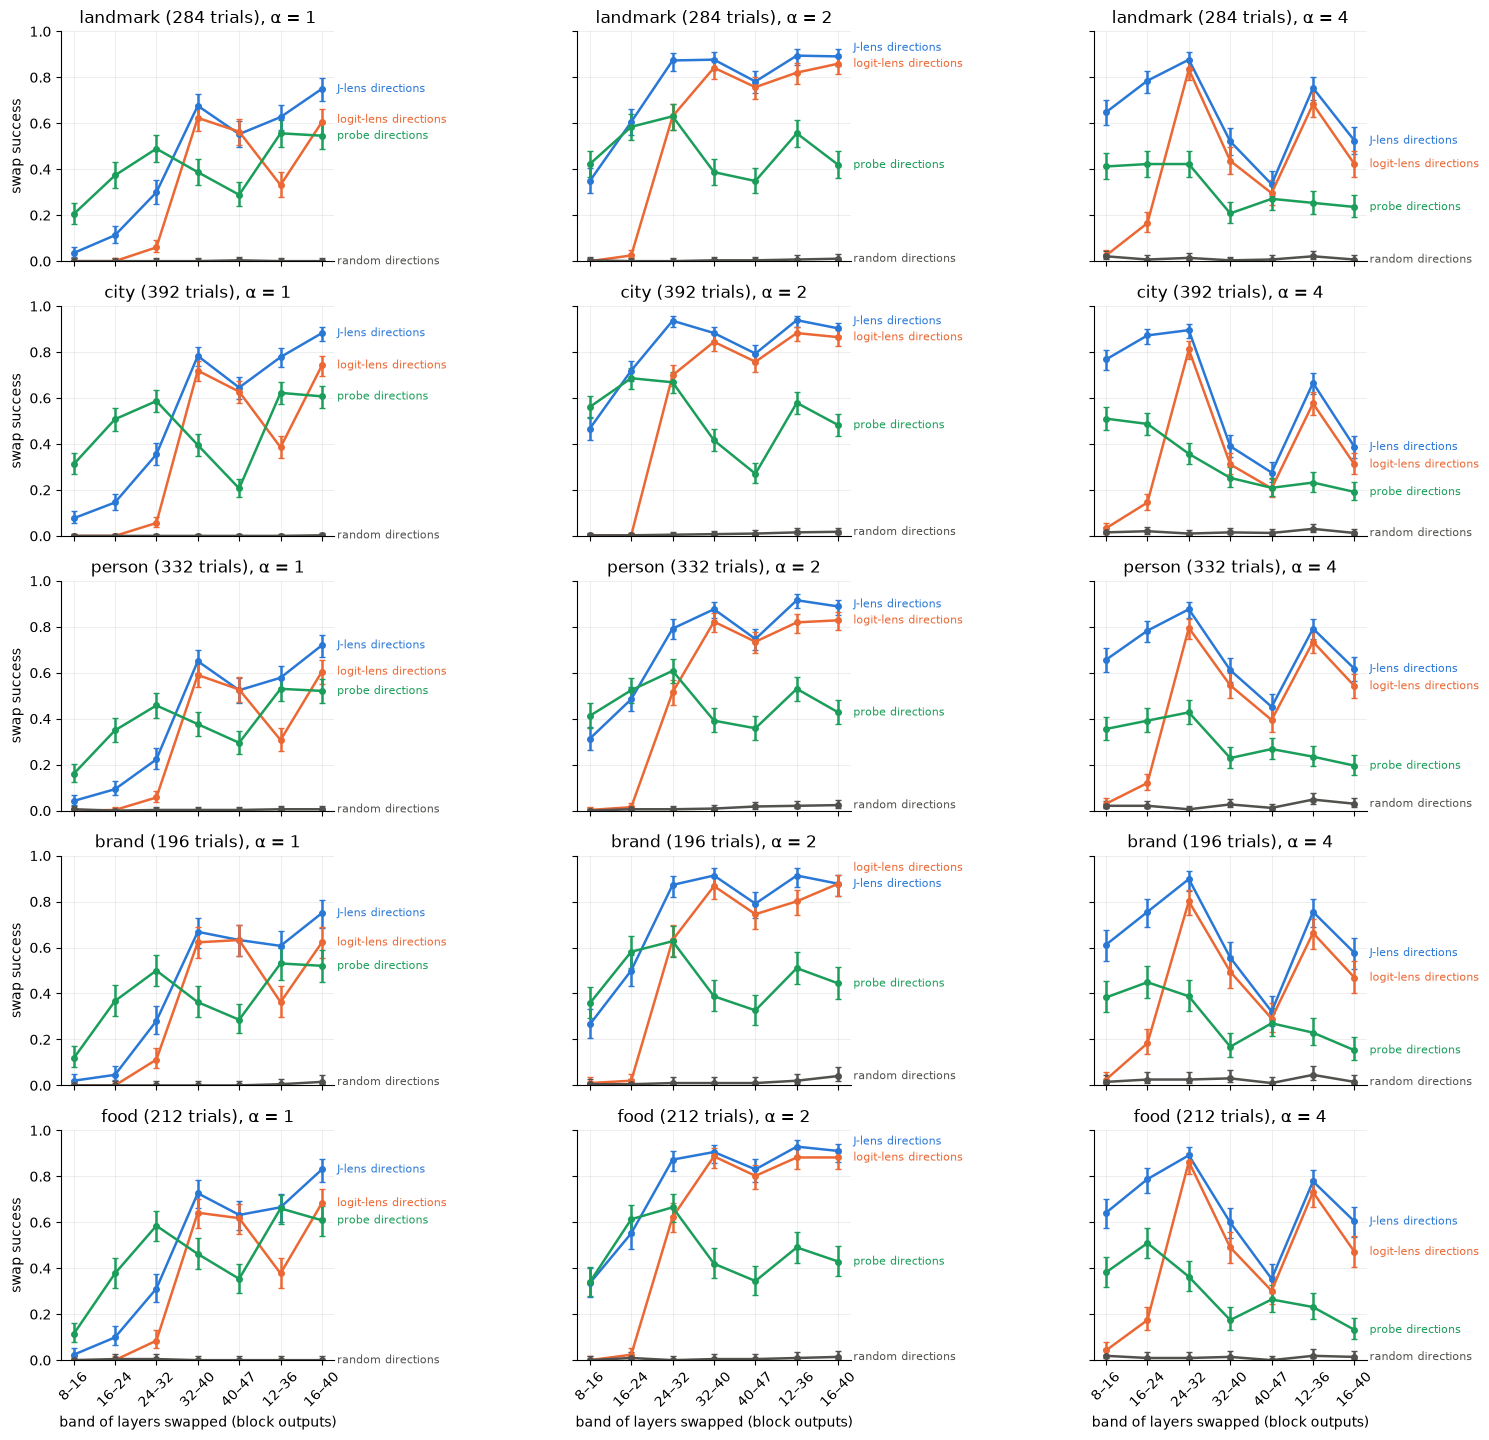

In [11]:
rows = []
for mode in MODES:
    setting = correct[correct["mode"].eq(mode) & correct.alpha.eq(best.loc[mode, "alpha"])
                      & correct.band.eq(best.loc[mode, "band"])]
    for family, group in setting.groupby("family", sort=False):
        lo, hi = wilson(group.success.sum(), len(group))
        rows.append({"mode": mode, "family": family, "n": len(group), "rate": group.success.mean(),
                     "CI lo": lo, "CI hi": hi})
by_family = pd.DataFrame(rows)
table = by_family.pivot(index="family", columns="mode", values="rate").loc[FAMILIES, MODES].round(3)
table.columns = [f"{NAMES[m]} (α = {best.loc[m, 'alpha']:g}, {band_label(best.loc[m, 'band'])})" for m in MODES]
display(table)

fig, axes = plt.subplots(len(FAMILIES), 3, figsize=(15, 2.9 * len(FAMILIES)), sharex=True, sharey=True)
for row_axes, family in zip(axes, FAMILIES, strict=True):
    frame = correct[correct.family.eq(family)]
    for ax, alpha in zip(row_axes, ALPHAS, strict=True):
        band_panel(ax, frame, alpha)
        ax.set_title(f"{family} ({frame.name.nunique()} trials), α = {alpha:g}")
    row_axes[0].set_ylabel("swap success")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BAND_TICKS, rotation=45)
    ax.set_xlabel("band of layers swapped (block outputs)")
fig.tight_layout(w_pad=9)
plt.show()

J-lens success by family across bands at the best α for J:

In [12]:
j_alpha = best.loc["J", "alpha"]
correct[correct["mode"].eq("J") & correct.alpha.eq(j_alpha)].groupby(["family", "band"]).success.mean().unstack(
    "band").loc[FAMILIES, BANDS].round(3)

band,8-16,16-24,24-32,32-40,40-47,12-36,16-40
family,,,,,,,
landmark,0.349,0.606,0.873,0.877,0.782,0.894,0.891
city,0.467,0.719,0.936,0.883,0.793,0.939,0.903
person,0.313,0.485,0.792,0.877,0.747,0.916,0.889
brand,0.265,0.500,0.872,0.913,0.791,0.913,0.878
food,0.335,0.552,0.873,0.906,0.830,0.929,0.910


### By country at the best J setting

Swapped-out (source) and swapped-in (target) country. Low rates for a target suggest the
model does not compose the swapped-in country with the template, low rates for a source that
the country's coordinates are not what carries it.

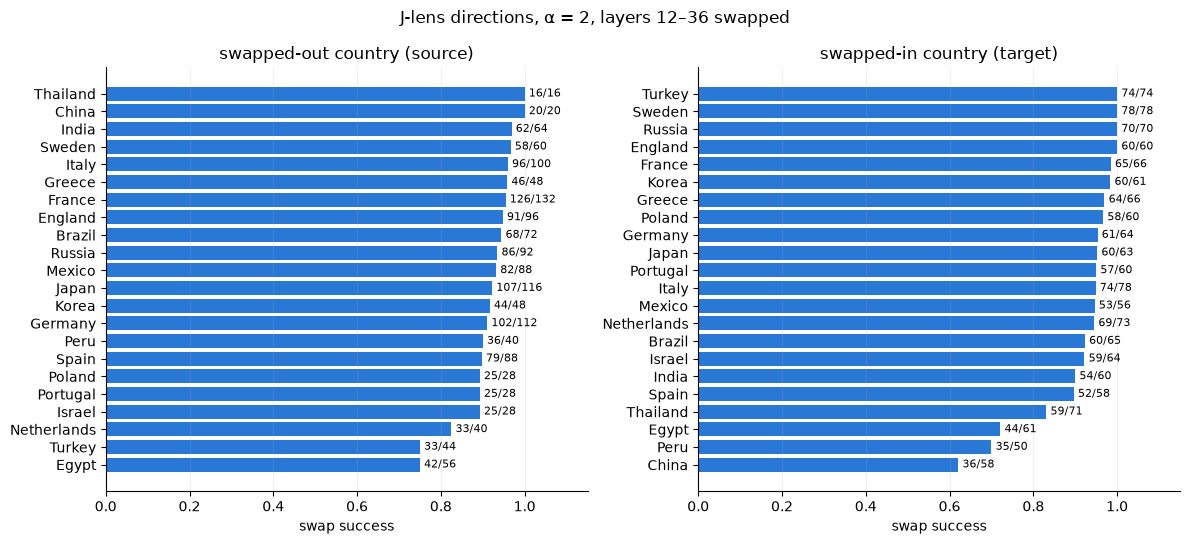

In [13]:
at_best = correct[correct["mode"].eq("J") & correct.alpha.eq(best.loc["J", "alpha"])
                  & correct.band.eq(best.loc["J", "band"])]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True)
for ax, column, title in zip(axes, ("source", "target"), ("swapped-out country (source)",
                                                          "swapped-in country (target)"), strict=True):
    table = at_best.groupby(column).success.agg(["sum", "size"]).assign(rate=lambda f: f["sum"] / f["size"])
    table = table.sort_values("rate")
    ax.barh(table.index, table.rate, color=COLORS["J"])
    for y, (hits, n) in enumerate(zip(table["sum"], table["size"], strict=True)):
        ax.text(table.rate.iloc[y] + 0.01, y, f"{hits}/{n}", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("swap success")
    ax.grid(axis="x", alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"J-lens directions, α = {best.loc['J', 'alpha']:g}, {band_label(best.loc['J', 'band'])} swapped")
fig.tight_layout()
plt.show()

What the model says when the best J swap fails:

In [14]:
failures = at_best[~at_best.success]
display(failures.groupby("family", sort=False).top1.agg(
    lambda s: ", ".join(f"{t!r}×{n}" for t, n in s.value_counts().head(6).items())).to_frame("top-1 on failures"))
failures.groupby("family", sort=False).head(3)[["name", "answer", "swap_answer", "top1", "rank_swap"]]

,top-1 on failures
family,
landmark,"' English'×12, ' Arabic'×9, ' Egyptian'×5, ' Peru'×2, ' Mandarin'×1, ' Chinese'×1"
food,"' Egyptian'×4, ' Cant'×4, ' Peru'×2, ' English'×2, ' Mandarin'×1, ' Mexican'×1"
city,"' Peru'×6, ' Arabic'×5, ' English'×4, ' Egyptian'×3, ' Mandarin'×3, ' Per'×1"
person,"' English'×10, ' Spanish'×4, ' French'×3, ' Egyptian'×2, ' Dutch'×2, ' Arabic'×2"
brand,"' English'×10, ' Mandarin'×4, ' Egyptian'×2, ' Arabic'×1"


,name,answer,swap_answer,top1,rank_swap
3920,Big Ben:England->Greece,English,Greek,English,2
3952,paella:Spain->Egypt,Spanish,Arabic,Egyptian,2
3955,paella:Spain->China,Spanish,Chinese,Cant,3
3959,tapas:Spain->Egypt,Spanish,Arabic,Egyptian,2
9312,Cologne Cathedral:Germany->Peru,German,Spanish,Peru,3
9313,Cologne Cathedral:Germany->Egypt,German,Arabic,Egyptian,2
14677,Manchester:England->Israel,English,Hebrew,Arabic,2
14694,Picasso:Spain->Brazil,Spanish,Portuguese,French,2
14700,Bach:Germany->China,German,Chinese,English,2
20055,Pele:Brazil->Egypt,Portuguese,Arabic,Egyptian,4


### Comparison with latent-bridge v1

`concept_swap.ipynb` ran the same grid on `latent-bridge` (landmarks only, baseline-correct
trials). Best setting per direction on each set:

In [15]:
if V1_CACHE.exists():
    v1 = pd.read_csv(V1_CACHE, keep_default_na=False)
    v1 = v1[v1.base_correct.astype(str).eq("True")]
    v1["success"] = v1.success.astype(str).eq("True")
    rows = []
    for name, frame in (("v1 (landmarks)", v1), ("v2 landmark", correct[correct.family.eq("landmark")]),
                        ("v2 all", correct)):
        g = frame.groupby(["mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
        top = g.loc[g.groupby("mode")["sum"].idxmax()]
        for row in top.itertuples():
            lo, hi = wilson(row.sum, row.size)
            rows.append({"set": name, "mode": row.mode, "alpha": row.alpha, "band": row.band,
                         "rate": row.sum / row.size, "CI": f"{lo:.2f}-{hi:.2f}", "n": row.size})
    display(pd.DataFrame(rows).pivot(index="mode", columns="set", values="rate").loc[MODES].round(3))
    display(pd.DataFrame(rows).set_index(["set", "mode"]).round(3))
else:
    print("no v1 cache at", V1_CACHE)

set,v1 (landmarks),v2 all,v2 landmark
mode,,,
J,0.884,0.919,0.894
logit,0.820,0.859,0.859
probe,NaN,0.641,0.630
random,0.039,0.033,0.021


alpha   band   rate         CI     n
set            mode                                        
v1 (landmarks) J         2.0  16-40  0.884  0.84-0.92   284
               logit     2.0  16-40  0.820  0.77-0.86   284
               random    4.0  12-36  0.039  0.02-0.07   284
v2 landmark    J         2.0  12-36  0.894  0.85-0.92   284
               logit     2.0  16-40  0.859  0.81-0.89   284
               probe     2.0  24-32  0.630  0.57-0.68   284
               random    4.0  12-36  0.021  0.01-0.05   284
v2 all         J         2.0  12-36  0.919  0.90-0.93  1416
               logit     2.0  16-40  0.859  0.84-0.88  1416
               probe     2.0  24-32  0.641  0.62-0.67  1416
               random    4.0  12-36  0.033  0.03-0.04  1416

## 4. Conclusions

* **The result of `latent-bridge` holds on a set 3.5× larger and five times more varied.** v1
  landmarks: J 88.4% (CI 84–92%); the v2 landmark family: 89.4%; all of v2: 91.9%. No family
  stands out: landmark 89%, person 92%, brand 91%, food 93%, city 94% at the pooled best setting.
* **J-lens directions carry the country in early and middle layers; logit-lens directions only
  late.** In late bands the two are close (32–40, α = 2: 88.8% vs 84.8%). Earlier the logit-lens
  swap does nothing: 16–24, α = 2: J 58.6% vs logit 1.6%; 8–16, α = 4: J 67.7% vs logit 3.1%.
* **Probes are weaker and work best early.** Difference-of-means probes peak at 64% (α = 2,
  24–32) and beat J only in early bands at α = 1 (8–16: 19.8% vs 4.4%; 16–24: 40.5% vs 10.6%),
  as on the paper's sets in `concept_swap.ipynb`.
* **α = 4 overshoots in late bands** (40–47: 34.7%), as in v1.
* **Most failures are on the swapped-in side and many are scoring misses.** Swaps *into* China
  (62%), Peru (70%), Egypt (72%) and Thailand (83%) fail most; the top-1 token is then often the
  right country in another form: ` Egyptian` instead of *Arabic*, ` Peru` / ` Per` instead of
  *Spanish*, ` Mandarin` / ` Cant` instead of *Chinese*, with the swap answer at rank 2–5. The rest
  are the default ` English` (people, companies) or the source answer kept. Egypt and Turkey are
  the hardest to swap *out* (75%).
* **Next:** accept the target country's demonym or name as a secondary "country moved" score,
  and compare where the swap must be applied (subject tokens vs the rest).